In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Read data

Dữ liệu bóng đá với các bảng chính sau:

- games: Thông tin các trận đấu (id, ngày, đội nhà, đội khách, tỉ số, sân vận động…).

- clubs: Dữ liệu các câu lạc bộ (id, tên, giải đấu nội địa, giá trị thị trường…).

- competitions: Thông tin giải đấu (id, tên, loại giải, quốc gia, cấp độ…).

- players: Dữ liệu cầu thủ (id, tên, quốc tịch, vị trí, chiều cao, CLB hiện tại…).

- appearances: Mỗi lần ra sân của cầu thủ (gắn với trận, cầu thủ, thống kê như bàn thắng, thẻ…).

- club_games: Thống kê đội bóng trong từng trận (bàn thắng, vị trí, HLV…).

- game_lineups: Đội hình xuất phát mỗi trận (cầu thủ, vị trí, số áo…).

- game_events: Sự kiện trong trận (bàn thắng, thẻ, kiến tạo…).

- transfer: Thông tin chuyển nhượng cầu thủ (từ CLB nào sang CLB nào, phí…).

- player_valuations: Giá trị cầu thủ theo thời gian.

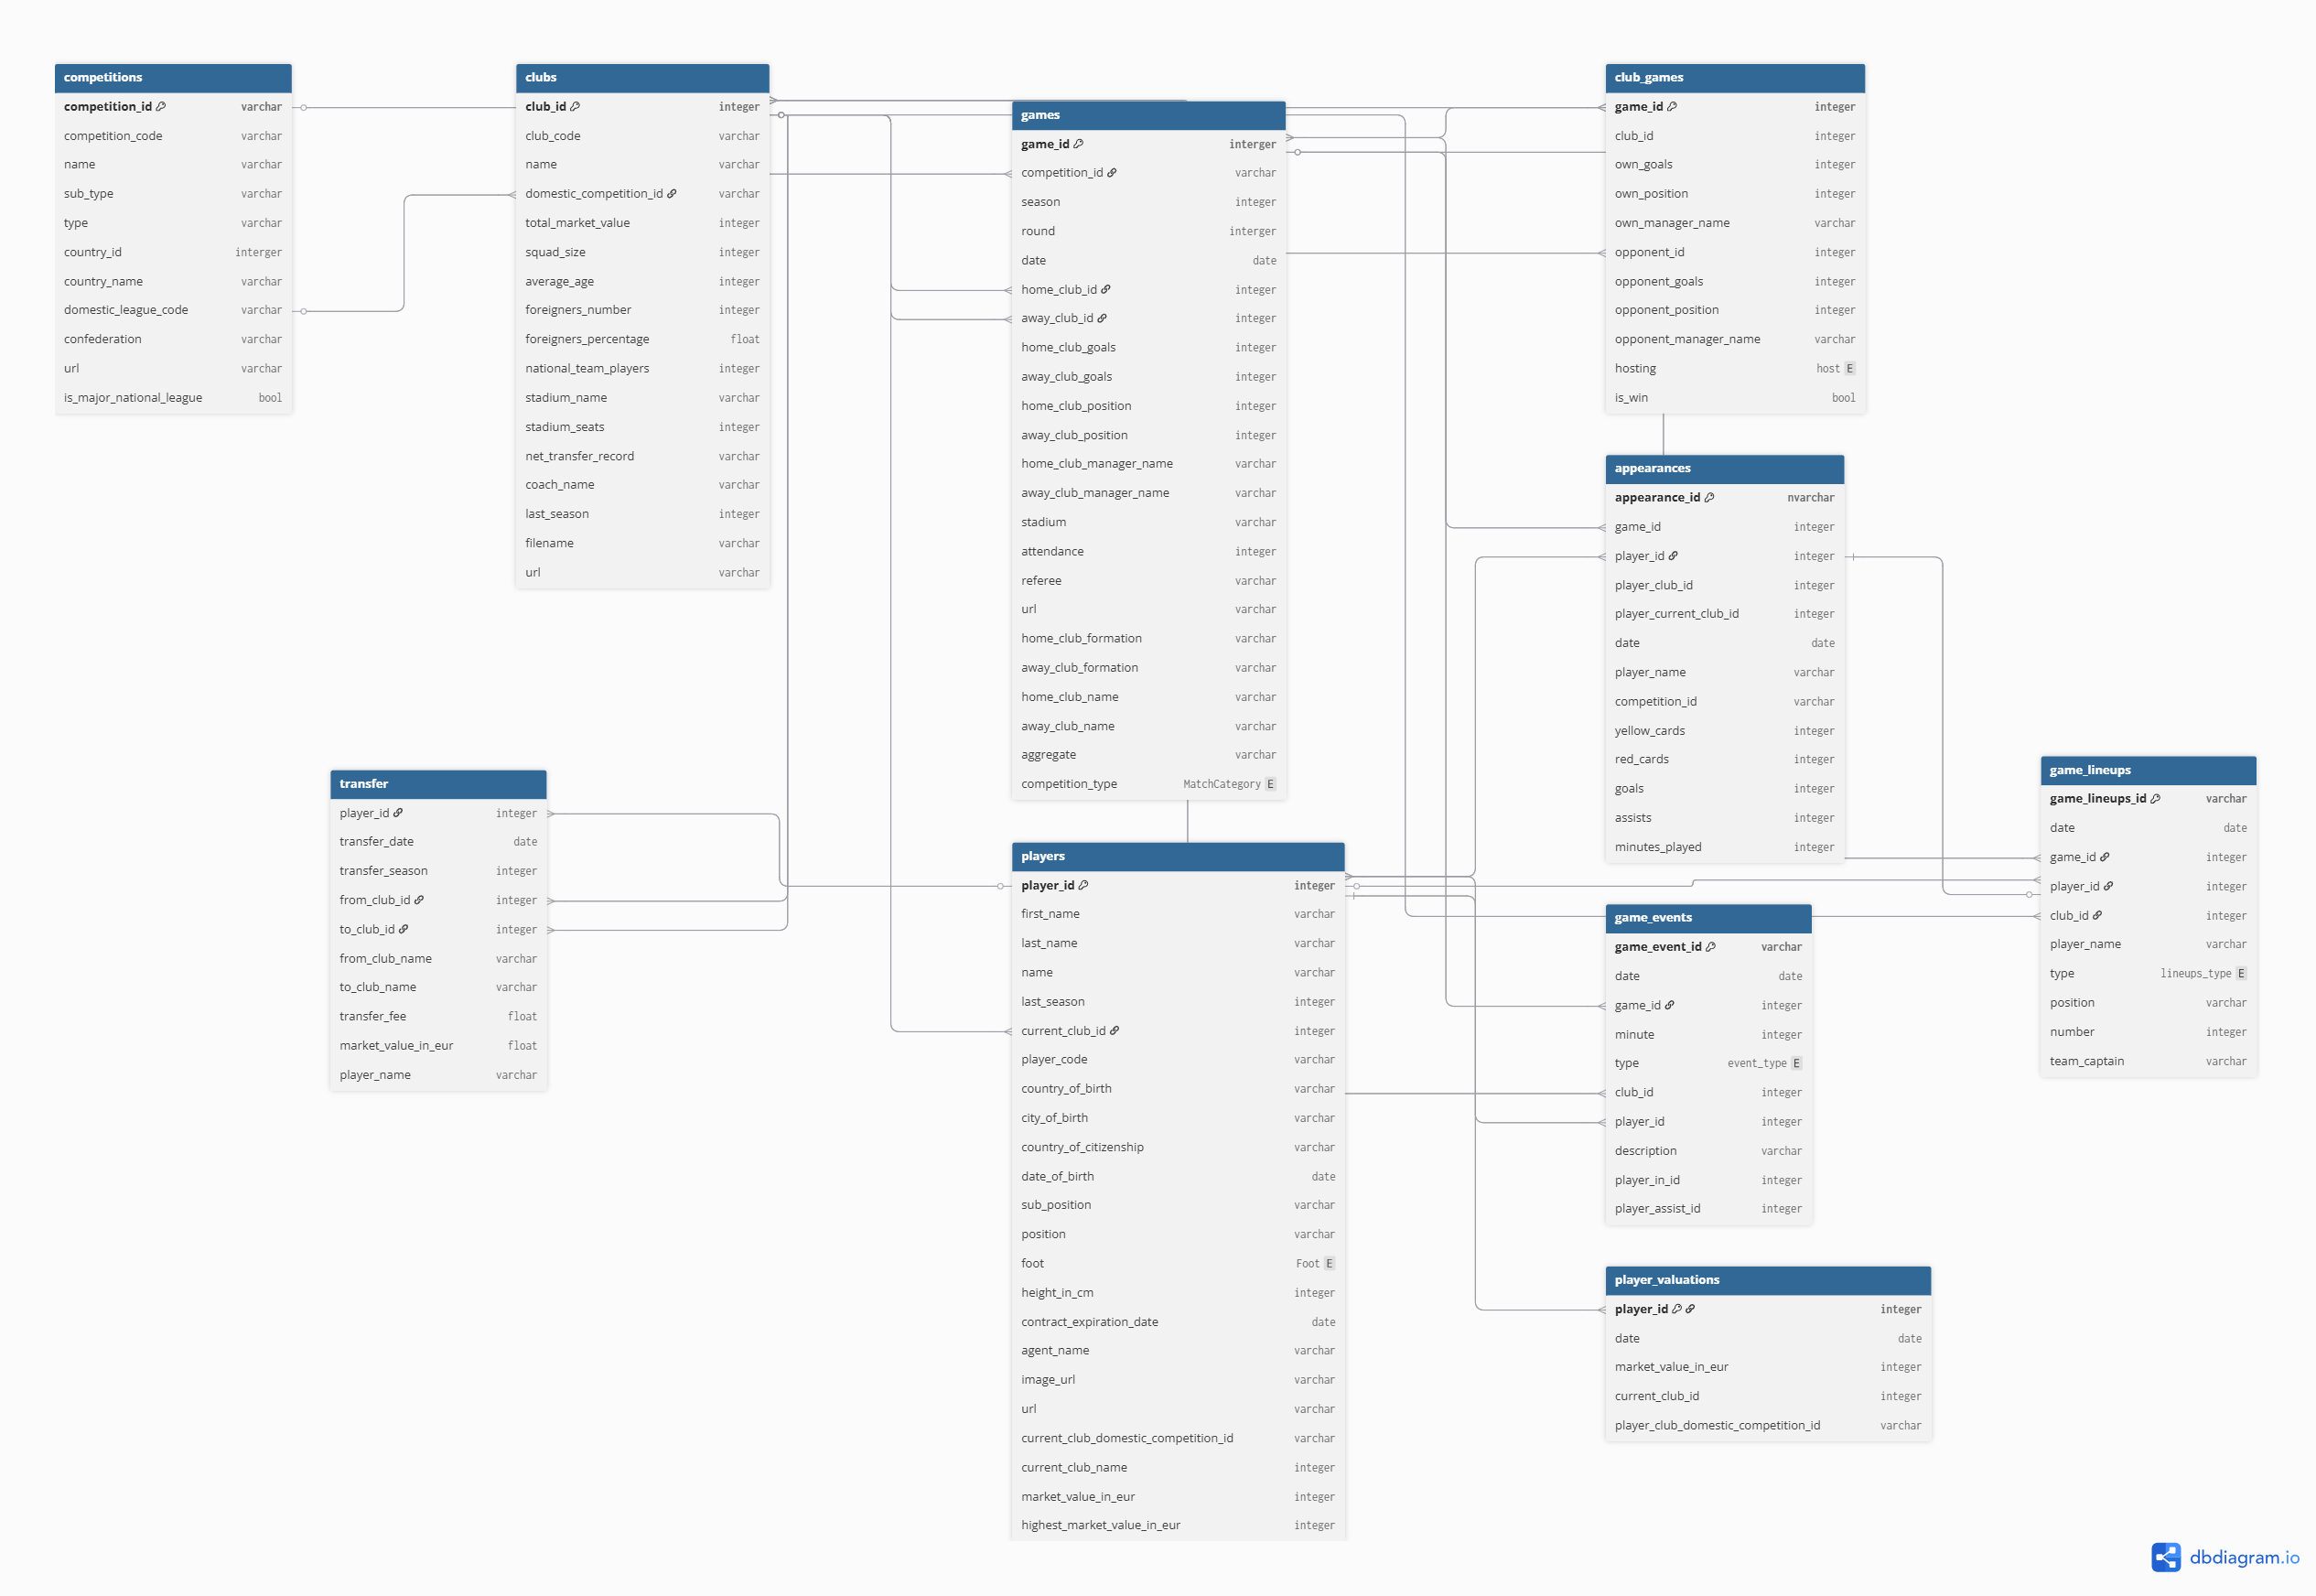

In [ ]:
games = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/games.csv')
games.head()

,game_id,competition_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,...,stadium,attendance,referee,url,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type
0,2321027,L1,2013,1. Matchday,2013-08-11,33.0,41.0,3.0,3.0,8.0,...,Veltins-Arena,61973.0,Manuel Gräfe,https://www.transfermarkt.co.uk/fc-schalke-04_...,4-2-3-1,4-2-3-1,FC Schalke 04,Hamburger SV,3:3,domestic_league
1,2321033,L1,2013,1. Matchday,2013-08-10,23.0,86.0,0.0,1.0,13.0,...,EINTRACHT-Stadion,23000.0,Deniz Aytekin,https://www.transfermarkt.co.uk/eintracht-brau...,4-3-2-1,4-3-1-2,Eintracht Braunschweig,Sportverein Werder Bremen von 1899,0:1,domestic_league
2,2321044,L1,2013,2. Matchday,2013-08-18,16.0,23.0,2.0,1.0,1.0,...,SIGNAL IDUNA PARK,80200.0,Peter Sippel,https://www.transfermarkt.co.uk/borussia-dortm...,4-2-3-1,4-3-2-1,Borussia Dortmund,Eintracht Braunschweig,2:1,domestic_league
3,2321060,L1,2013,3. Matchday,2013-08-25,23.0,24.0,0.0,2.0,18.0,...,EINTRACHT-Stadion,23325.0,Wolfgang Stark,https://www.transfermarkt.co.uk/eintracht-brau...,4-3-2-1,4-2-3-1,Eintracht Braunschweig,Eintracht Frankfurt Fußball AG,0:2,domestic_league
4,2321072,L1,2013,5. Matchday,2013-09-14,16.0,41.0,6.0,2.0,1.0,...,SIGNAL IDUNA PARK,80645.0,Tobias Welz,https://www.transfermarkt.co.uk/borussia-dortm...,4-2-3-1,3-5-2,Borussia Dortmund,Hamburger SV,6:2,domestic_league


### games table features:

- `game_id`: ID duy nhất cho mỗi trận đấu.
- `competition_id`: ID của giải đấu mà trận đấu đó thuộc về.
- `season`: Mùa giải của trận đấu.
- `round`: Vòng đấu của giải đấu (ví dụ: "Vòng bảng", "Chung kết").
- `date`: Ngày diễn ra trận đấu.
- `home_club_id`: ID của đội chủ nhà.
- `away_club_id`: ID của đội khách.
- `home_club_goals`: Số bàn thắng của đội chủ nhà.
- `away_club_goals`: Số bàn thắng của đội khách.
- `home_club_position`: Vị trí của đội chủ nhà trên bảng xếp hạng tại thời điểm trận đấu diễn ra.
- `away_club_position`: Vị trí của đội khách trên bảng xếp hạng tại thời điểm trận đấu diễn ra.
- `home_club_manager_name`: Tên huấn luyện viên đội chủ nhà.
- `away_club_manager_name`: Tên huấn luyện viên đội khách.
- `stadium`: Tên sân vận động nơi trận đấu được diễn ra.
- `attendance`: Số lượng khán giả tại trận đấu.
- `referee`: Tên trọng tài.
- `url`: URL của trận đấu trên Transfermarkt.
- `home_club_formation`: Đội hình được đội chủ nhà sử dụng.
- `away_club_formation`: Đội hình được đội khách sử dụng.
- `home_club_name`: Tên đội chủ nhà.
- `away_club_name`: Tên đội khách.
- `aggregate`: Tổng điểm qua hai lượt trận (cho vòng loại trực tiếp).
- `competition_type`: Loại cuộc thi (ví dụ: "domestic_league", "international_cup").

In [ ]:
club_games = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/club_games.csv')
club_games.head()

,game_id,club_id,own_goals,own_position,own_manager_name,opponent_id,opponent_goals,opponent_position,opponent_manager_name,hosting,is_win
0,2320450,1468.0,0.0,NaN,Holger Bachthaler,24.0,2.0,NaN,Armin Veh,Home,0
1,2320454,222.0,0.0,NaN,Volkan Uluc,79.0,2.0,NaN,Bruno Labbadia,Home,0
2,2320460,1.0,3.0,NaN,Jürgen Luginger,86.0,1.0,NaN,Robin Dutt,Home,1
3,2320472,2036.0,4.0,NaN,Frank Schmidt,72.0,5.0,NaN,Alexander Schmidt,Home,0
4,2321027,33.0,3.0,8.0,Jens Keller,41.0,3.0,9.0,Thorsten Fink,Home,0


### club_games table features:

- `game_id`: ID duy nhất của trận đấu.
- `club_id`: ID của câu lạc bộ.
- `own_goals`: Số bàn thắng được ghi bởi câu lạc bộ này trong trận đấu.
- `own_position`: Vị trí của câu lạc bộ này trong giải đấu tại thời điểm diễn ra trận đấu.
- `own_manager_name`: Huấn luyện viên của câu lạc bộ này.
- `opponent_id`: ID của câu lạc bộ đối phương.
- `opponent_goals`: Số bàn thắng được ghi bởi câu lạc bộ đối phương.
- `opponent_position`: Vị trí của câu lạc bộ đối phương trong giải đấu tại thời điểm diễn ra trận đấu.
- `opponent_manager_name`: Huấn luyện viên của câu lạc bộ đối phương.
- `hosting`: Cho biết câu lạc bộ là đội chủ nhà ('Chủ nhà') hay đội khách ('Khách').
- `is_win`: Chỉ báo nhị phân (1 nếu câu lạc bộ thắng, 0 nếu ngược lại).

In [ ]:
clubs = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/clubs.csv')
clubs.head()

,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,105,sv-darmstadt-98,SV Darmstadt 98,L1,NaN,27,25.6,13,48.1,1,Merck-Stadion am Böllenfalltor,17810,+€3.05m,NaN,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/sv-darmstadt-9...
1,11127,ural-ekaterinburg,Ural Yekaterinburg,RU1,NaN,30,26.5,11,36.7,3,Yekaterinburg Arena,23000,+€880k,NaN,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/ural-ekaterinb...
2,114,besiktas-istanbul,Beşiktaş Jimnastik Kulübü,TR1,NaN,30,26.6,15,50.0,8,Beşiktaş Park,42445,€-25.26m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/besiktas-istan...
3,12,as-rom,Associazione Sportiva Roma,IT1,NaN,26,26.3,18,69.2,17,Olimpico di Roma,70634,€-76.90m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/as-rom/startse...
4,148,tottenham-hotspur,Tottenham Hotspur Football Club,GB1,NaN,30,25.5,21,70.0,18,Tottenham Hotspur Stadium,62850,€-120.05m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/tottenham-hots...


### clubs table features:

- `club_id`: Mã định danh duy nhất của câu lạc bộ.
- `club_code`: Mã ngắn của câu lạc bộ.
- `name`: Tên đầy đủ của câu lạc bộ.
- `domestic_competition_id`: Mã định danh giải đấu quốc nội của câu lạc bộ.
- `total_market_value`: Tổng giá trị thị trường của đội hình câu lạc bộ (tính bằng Euro).
- `squad_size`: Số lượng cầu thủ trong đội hình.
- `average_age`: Độ tuổi trung bình của các cầu thủ trong đội hình.
- `foreigners_number`: Số lượng cầu thủ nước ngoài trong đội hình.
- `foreigners_percentage`: Tỷ lệ phần trăm cầu thủ nước ngoài trong đội hình.
- `national_team_players`: Số lượng cầu thủ hiện đang là cầu thủ đội tuyển quốc gia.
- `stadium_name`: Tên sân vận động của câu lạc bộ.
- `stadium_seats`: Sức chứa của sân vận động câu lạc bộ.
- `net_transfer_record`: Chi tiêu/thu nhập chuyển nhượng ròng của câu lạc bộ.
- `coach_name`: Tên huấn luyện viên của câu lạc bộ.
- `last_season`: Dữ liệu câu lạc bộ đã được cập nhật vào mùa giải trước.
- `filename`: Tên tệp nguồn của dữ liệu.
- `url`: URL của câu lạc bộ trên Transfermarkt.

In [ ]:
game_events = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/game_events.csv', engine='python', on_bad_lines='skip')
game_events.head()

,game_event_id,date,game_id,minute,type,club_id,player_id,description,player_in_id,player_assist_id
0,2f41da30c471492e7d4a984951671677,2012-08-05,2211607,77,Cards,610,4425,"1. Yellow card , Mass confrontation",NaN,NaN
1,a72f7186d132775f234d3e2f7bc0ed5b,2012-08-05,2211607,77,Cards,383,33210,"1. Yellow card , Mass confrontation",NaN,NaN
2,b2d721eaed4692a5c59a92323689ef18,2012-08-05,2211607,3,Goals,383,36500,", Header, 1. Tournament Goal Assist: , Corner,...",NaN,56416.0
3,aef768899cedac0c9a650980219075a2,2012-08-05,2211607,53,Goals,383,36500,", Right-footed shot, 2. Tournament Goal Assist...",NaN,146258.0
4,5d6d9533023057b6619ecd145a038bbe,2012-08-05,2211607,74,Substitutions,383,36500,", Not reported",49499.0,NaN


### game_events table features:

- `game_event_id`: ID duy nhất cho mỗi sự kiện.
- `date`: Ngày diễn ra trận đấu.
- `game_id`: ID của trận đấu.
- `minute`: Phút của trận đấu mà sự kiện diễn ra.
- `type`: Loại sự kiện (ví dụ: "Bàn thắng", "Thẻ", "Thay người").
- `club_id`: ID của câu lạc bộ tham gia sự kiện.
- `player_id`: ID của cầu thủ tham gia sự kiện.
- `description`: Mô tả sự kiện.
- `player_in_id`: ID của cầu thủ vào sân (để thay người).
- `player_assist_id`: ID của cầu thủ kiến tạo (ghi bàn).

In [ ]:
competitions = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/competitions.csv', index_col=0)
competitions.head()

,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,url,is_major_national_league
competition_id,,,,,,,,,,
CIT,italy-cup,italy-cup,domestic_cup,domestic_cup,75,Italy,IT1,europa,https://www.transfermarkt.co.uk/italy-cup/star...,False
NLSC,johan-cruijff-schaal,johan-cruijff-schaal,domestic_super_cup,other,122,Netherlands,NL1,europa,https://www.transfermarkt.co.uk/johan-cruijff-...,False
GRP,kypello-elladas,kypello-elladas,domestic_cup,domestic_cup,56,Greece,GR1,europa,https://www.transfermarkt.co.uk/kypello-ellada...,False
POSU,supertaca-candido-de-oliveira,supertaca-candido-de-oliveira,domestic_super_cup,other,136,Portugal,PO1,europa,https://www.transfermarkt.co.uk/supertaca-cand...,False
RUSS,russian-super-cup,russian-super-cup,domestic_super_cup,other,141,Russia,RU1,europa,https://www.transfermarkt.co.uk/russian-super-...,False


### competitions table features:

- `competition_id`: ID duy nhất cho mỗi giải đấu.
- `competition_code`: Mã ngắn gọn của giải đấu.
- `name`: Tên đầy đủ của giải đấu.
- `sub_type`: Loại phụ của giải đấu (ví dụ: "domestic_cup", "domestic_super_cup").
- `type`: Loại giải đấu (ví dụ: "domestic_cup", "other", "international_cup").
- `country_id`: ID của quốc gia tổ chức giải đấu.
- `country_name`: Tên quốc gia tổ chức giải đấu.
- `domestic_league_code`: Mã của giải đấu quốc nội liên quan đến giải đấu.
- `confederation`: Liên đoàn bóng đá mà giải đấu thuộc về (ví dụ: "europa").
- `url`: URL của giải đấu trên Transfermarkt.
- `is_major_national_league`: Chỉ báo nhị phân (Đúng nếu đó là một giải đấu quốc gia lớn).

In [ ]:
game_lineups = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/game_lineups.csv')
game_lineups.head()

,game_lineups_id,date,game_id,player_id,club_id,player_name,type,position,number,team_captain
0,b2dbe01c3656b06c8e23e9de714e26bb,2013-07-27,2317258,1443,610,Christian Poulsen,substitutes,Defensive Midfield,5,0
1,b50a3ec6d52fd1490aab42042ac4f738,2013-07-27,2317258,5017,610,Niklas Moisander,starting_lineup,Centre-Back,4,0
2,7d890e6d0ff8af84b065839966a0ec81,2013-07-27,2317258,9602,1090,Maarten Martens,substitutes,Left Winger,11,0
3,8c355268678b9bbc7084221b1f0fde36,2013-07-27,2317258,12282,610,Daley Blind,starting_lineup,Left-Back,17,0
4,76193074d549e5fdce4cdcbba0d66247,2013-07-27,2317258,25427,1090,Roy Beerens,starting_lineup,Right Winger,23,0


### game_lineups table features:

- `game_lineups_id`: ID duy nhất cho mỗi mục nhập đội hình.
- `date`: Ngày diễn ra trận đấu.
- `game_id`: ID của trận đấu.
- `player_id`: ID của cầu thủ trong đội hình.
- `club_id`: ID của câu lạc bộ mà cầu thủ đó thuộc về trong trận đấu này.
- `player_name`: Tên của cầu thủ.
- `type`: Cho biết cầu thủ đó nằm trong 'starting_lineup' hay 'substitutes'.
- `position`: Vị trí của cầu thủ trong đội hình.
- `number`: Số áo của cầu thủ.
- `team_captain`: Chỉ báo nhị phân (1 nếu cầu thủ là đội trưởng, 0 nếu không).

In [ ]:
players = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/players.csv')
players.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


### players table features:

- `player_id`: ID duy nhất cho mỗi cầu thủ.
- `first_name`: Tên của cầu thủ.
- `last_name`: Họ của cầu thủ.
- `name`: Họ đầy đủ của cầu thủ.
- `last_season`: Dữ liệu cầu thủ đã được cập nhật trong mùa giải trước.
- `current_club_id`: ID câu lạc bộ hiện tại của cầu thủ.
- `player_code`: Mã ngắn của cầu thủ.
- `country_of_birth`: Quốc gia nơi cầu thủ sinh ra.
- `city_of_birth`: Thành phố nơi cầu thủ sinh ra.
- `country_of_citizenship`: Quốc gia nơi cầu thủ mang quốc tịch.
- `date_of_birth`: Ngày sinh của cầu thủ.
- `sub_position`: Vị trí cụ thể hơn của cầu thủ.
- `position`: Vị trí chung của cầu thủ.
- `foot`: Chân thuận của cầu thủ.
- `height_in_cm`: Chiều cao của cầu thủ tính bằng cm.
- `contract_expiration_date`: Ngày hết hạn hợp đồng của cầu thủ.
- `agent_name`: Tên người đại diện của cầu thủ.
- `image_url`: URL hình ảnh của cầu thủ.
- `url`: URL của cầu thủ trên Transfermarkt.
- `current_club_domestic_competition_id`: ID giải đấu quốc nội của câu lạc bộ hiện tại của cầu thủ.
- `current_club_name`: Tên câu lạc bộ hiện tại của cầu thủ.
- `market_value_in_eur`: Giá trị thị trường hiện tại của cầu thủ tính bằng Euro.
- `highest_market_value_in_eur`: Giá trị thị trường cao nhất được ghi nhận của cầu thủ tính bằng Euro.

In [ ]:
appearances = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/appearances.csv')
appearances.head()

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


### appearances table features:

- `appearance_id`: ID duy nhất cho mỗi lần xuất hiện của cầu thủ trong một trận đấu.
- `game_id`: ID của trận đấu.
- `player_id`: ID của cầu thủ.
- `player_club_id`: ID của câu lạc bộ mà cầu thủ đã chơi trong trận đấu này.
- `player_current_club_id`: ID của câu lạc bộ hiện tại của cầu thủ (có thể khác với `player_club_id` nếu được chuyển nhượng).
- `date`: Ngày diễn ra trận đấu.
- `player_name`: Tên cầu thủ.
- `competition_id`: ID của giải đấu.
- `yellow_cards`: Số thẻ vàng mà cầu thủ nhận được trong trận đấu này.
- `red_cards`: Số thẻ đỏ mà cầu thủ nhận được trong trận đấu này.
- `goals`: Số bàn thắng mà cầu thủ ghi được trong trận đấu này.
- `assists`: Số pha kiến tạo mà cầu thủ thực hiện trong trận đấu này.
- `minutes_played`: Số phút cầu thủ đã chơi trong trận đấu này.

In [ ]:
player_valuations = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/player_valuations.csv')
player_valuations.head()

,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


### player_valuations table features:

- `player_id`: ID duy nhất của cầu thủ.
- `date`: Ngày cập nhật giá trị thị trường.
- `market_value_in_eur`: Giá trị thị trường của cầu thủ tính bằng Euro vào ngày này.
- `current_club_id`: ID câu lạc bộ của cầu thủ vào ngày này.
- `player_club_domestic_competition_id`: ID giải đấu quốc nội của câu lạc bộ của cầu thủ vào ngày này.

In [ ]:
transfers = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/transfers.csv')
transfers.head()

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,16136,2026-07-01,26/27,417,123,OGC Nice,Retired,NaN,500000.0,Dante
1,1138758,2026-07-01,26/27,336,631,Sporting CP,Chelsea,52140000.0,45000000.0,Geovany Quenda
2,195778,2026-06-30,25/26,79,27,VfB Stuttgart,Bayern Munich,0.0,12000000.0,Alexander Nübel
3,569033,2026-06-30,25/26,39,27,1.FSV Mainz 05,Bayern Munich,0.0,4000000.0,Armindo Sieb
4,626913,2026-06-30,25/26,398,380,Lazio,Salernitana,0.0,15000000.0,Boulaye Dia


### transfers table features:

- `player_id`: ID duy nhất của cầu thủ được chuyển nhượng.
- `transfer_date`: Ngày chuyển nhượng.
- `transfer_season`: Mùa chuyển nhượng.
- `from_club_id`: ID của câu lạc bộ mà cầu thủ được chuyển nhượng.
- `to_club_id`: ID của câu lạc bộ mà cầu thủ được chuyển nhượng đến.
- `from_club_name`: Tên câu lạc bộ mà cầu thủ được chuyển nhượng.
- `to_club_name`: Tên câu lạc bộ mà cầu thủ được chuyển nhượng đến.
- `transfer_fee`: Phí chuyển nhượng (tính bằng Euro).
- `market_value_in_eur`: Giá trị thị trường của cầu thủ tại thời điểm chuyển nhượng (tính bằng Euro).
- `player_name`: Tên cầu thủ được chuyển nhượng.

# Preprocessing

- Tải dữ liệu: Tải từng tệp CSV vào một DataFrame của Pandas.
- Khám phá dữ liệu ban đầu: Đối với mỗi DataFrame, hãy thực hiện khám phá ban đầu để hiểu cấu trúc, kiểu dữ liệu và xác định các giá trị bị thiếu. Điều này bao gồm sử dụng các hàm .info(), .describe() và .isnull().sum().
- Xử lý các giá trị bị thiếu: Dựa trên bản chất và tỷ lệ phần trăm dữ liệu bị thiếu trong mỗi cột, hãy quyết định một chiến lược phù hợp. Điều này có thể bao gồm việc loại bỏ các cột có tỷ lệ giá trị bị thiếu cao, loại bỏ các hàng có giá trị bị thiếu trong các cột quan trọng hoặc tính giá trị bị thiếu bằng phương pháp trung bình, trung vị, mốt hoặc một phương pháp phức tạp hơn.
- Xử lý các giá trị trùng lặp: Kiểm tra và loại bỏ các hàng trùng lặp trong mỗi DataFrame.

### Preprocessing bảng `games`

In [ ]:
games.info()
games.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74026 entries, 0 to 74025
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 74026 non-null  int64  
 1   competition_id          74026 non-null  object 
 2   season                  74026 non-null  int64  
 3   round                   74026 non-null  object 
 4   date                    74026 non-null  object 
 5   home_club_id            74017 non-null  float64
 6   away_club_id            74017 non-null  float64
 7   home_club_goals         74014 non-null  float64
 8   away_club_goals         74014 non-null  float64
 9   home_club_position      51559 non-null  float64
 10  away_club_position      51559 non-null  float64
 11  home_club_manager_name  73198 non-null  object 
 12  away_club_manager_name  73198 non-null  object 
 13  stadium                 73776 non-null  object 
 14  attendance              64078 non-null

,game_id,season,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,attendance
count,7.402600e+04,74026.000000,7.401700e+04,7.401700e+04,74014.000000,74014.000000,51559.000000,51559.000000,64078.000000
mean,3.165280e+06,2017.981939,5.324385e+03,4.811172e+03,1.600400,1.331599,9.273667,9.453345,18346.864821
std,6.679408e+05,3.740290,3.114291e+04,3.068594e+04,1.433323,1.370649,5.297962,5.317900,17950.346007
min,2.211607e+06,2012.000000,1.000000e+00,2.000000e+00,0.000000,0.000000,1.000000,1.000000,1.000000
25%,2.587785e+06,2015.000000,3.540000e+02,3.470000e+02,1.000000,0.000000,5.000000,5.000000,4400.000000
50%,3.080342e+06,2018.000000,9.950000e+02,9.870000e+02,1.000000,1.000000,9.000000,9.000000,12400.000000
75%,3.646236e+06,2021.000000,3.209000e+03,3.037000e+03,2.000000,2.000000,14.000000,14.000000,26718.500000
max,4.572898e+06,2024.000000,4.506872e+06,4.506873e+06,17.000000,19.000000,21.000000,21.000000,99354.000000


In [ ]:
# 1. Đổi kiểu ngày
games['date'] = pd.to_datetime(games['date'], errors='coerce')

# 2. Xoá dòng thiếu dữ liệu quan trọng
required_cols = ['home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals']
games = games.dropna(subset=required_cols)

# 3. Xử lý kiểu dữ liệu số
games['home_club_id'] = games['home_club_id'].astype(int)
games['away_club_id'] = games['away_club_id'].astype(int)

# 4. Loại bỏ các cột không cần thiết cho mô hình (dư thừa hoặc không học được gì)
cols_to_drop = [
    'url', 'aggregate',
    'home_club_name', 'away_club_name',
    'referee', 'stadium',
    'home_club_manager_name', 'away_club_manager_name'
]
games.drop(columns=[col for col in cols_to_drop if col in games.columns], inplace=True)

# 5. Mã hóa categorical (competition_type, formation,...)
categorical_cols = ['competition_type', 'home_club_formation', 'away_club_formation']

for col in categorical_cols:
    if col in games.columns:
        games[col] = games[col].astype(str).fillna("Unknown")
        games[col] = LabelEncoder().fit_transform(games[col])

# 6. Kiểm tra kết quả
print("Bảng games sau xử lý:")
print(games.info())

Bảng games sau xử lý:
<class 'pandas.core.frame.DataFrame'>
Index: 74014 entries, 0 to 74025
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   game_id              74014 non-null  int64         
 1   competition_id       74014 non-null  object        
 2   season               74014 non-null  int64         
 3   round                74014 non-null  object        
 4   date                 74014 non-null  datetime64[ns]
 5   home_club_id         74014 non-null  int64         
 6   away_club_id         74014 non-null  int64         
 7   home_club_goals      74014 non-null  float64       
 8   away_club_goals      74014 non-null  float64       
 9   home_club_position   51559 non-null  float64       
 10  away_club_position   51559 non-null  float64       
 11  attendance           64078 non-null  float64       
 12  home_club_formation  74014 non-null  int64         
 13  away_club_form

### Preprocessing `club_games` table

In [ ]:
club_games.info()
club_games.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148052 entries, 0 to 148051
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   game_id                148052 non-null  int64  
 1   club_id                148034 non-null  float64
 2   own_goals              148028 non-null  float64
 3   own_position           103118 non-null  float64
 4   own_manager_name       146396 non-null  object 
 5   opponent_id            148034 non-null  float64
 6   opponent_goals         148028 non-null  float64
 7   opponent_position      103118 non-null  float64
 8   opponent_manager_name  146396 non-null  object 
 9   hosting                148052 non-null  object 
 10  is_win                 148052 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 12.4+ MB


,game_id,club_id,own_goals,own_position,opponent_id,opponent_goals,opponent_position,is_win
count,1.480520e+05,1.480340e+05,148028.000000,103118.000000,1.480340e+05,148028.000000,103118.000000,148052.000000
mean,3.165280e+06,5.067779e+03,1.466000,9.363506,5.067779e+03,1.466000,9.363506,0.392808
std,6.679385e+05,3.091623e+04,1.408757,5.308675,3.091623e+04,1.408757,5.308675,0.488376
min,2.211607e+06,1.000000e+00,0.000000,1.000000,1.000000e+00,0.000000,1.000000,0.000000
25%,2.587784e+06,3.540000e+02,0.000000,5.000000,3.540000e+02,0.000000,5.000000,0.000000
50%,3.080342e+06,9.890000e+02,1.000000,9.000000,9.890000e+02,1.000000,9.000000,0.000000
75%,3.646236e+06,3.060000e+03,2.000000,14.000000,3.060000e+03,2.000000,14.000000,1.000000
max,4.572898e+06,4.506873e+06,19.000000,21.000000,4.506873e+06,19.000000,21.000000,1.000000


In [ ]:
# 1. Xoá dòng trùng
club_games = club_games.drop_duplicates()

# 2. Xoá cột có quá nhiều missing (>30%)
missing_ratio = club_games.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.3].index
club_games = club_games.drop(columns=cols_to_drop)

# 3. Điền missing còn lại bằng trung bình (numeric) hoặc 'Unknown' (categorical)
for col in club_games.columns:
    if club_games[col].dtype == 'object':
        club_games[col] = club_games[col].astype(str).fillna("Unknown")
    else:
        club_games[col] = club_games[col].fillna(club_games[col].mean())

# 4. Mã hóa categorical nếu có
for col in club_games.select_dtypes(include='object').columns:
    club_games[col] = LabelEncoder().fit_transform(club_games[col])

# 5. Kiểu dữ liệu chuẩn
club_games['game_id'] = club_games['game_id'].astype(int)
club_games['club_id'] = club_games['club_id'].astype(int)

# 6. Kiểm tra kết quả
print("Bảng club_games sau xử lý:")
print(club_games.info())

Bảng club_games sau xử lý:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148052 entries, 0 to 148051
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   game_id                148052 non-null  int64  
 1   club_id                148052 non-null  int64  
 2   own_goals              148052 non-null  float64
 3   own_manager_name       148052 non-null  int64  
 4   opponent_id            148052 non-null  float64
 5   opponent_goals         148052 non-null  float64
 6   opponent_manager_name  148052 non-null  int64  
 7   hosting                148052 non-null  int64  
 8   is_win                 148052 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 10.2 MB
None


### Preprocessing bảng `clubs`

In [ ]:
clubs.info()
print(clubs.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   club_id                  439 non-null    int64  
 1   club_code                439 non-null    object 
 2   name                     439 non-null    object 
 3   domestic_competition_id  439 non-null    object 
 4   total_market_value       0 non-null      float64
 5   squad_size               439 non-null    int64  
 6   average_age              401 non-null    float64
 7   foreigners_number        439 non-null    int64  
 8   foreigners_percentage    390 non-null    float64
 9   national_team_players    439 non-null    int64  
 10  stadium_name             439 non-null    object 
 11  stadium_seats            439 non-null    int64  
 12  net_transfer_record      439 non-null    object 
 13  coach_name               0 non-null      float64
 14  last_season              4

In [ ]:

# 1. Drop duplicates
clubs = clubs.drop_duplicates()

# 2. Drop các cột không cần thiết cho mô hình
drop_cols = ['filename', 'url', 'stadium_name', 'coach_name']  
clubs = clubs.drop(columns=[col for col in drop_cols if col in clubs.columns])

# 3. Xử lý missing
if clubs['total_market_value'].isnull().all():
    clubs.drop(columns=['total_market_value'], inplace=True)
else:
    clubs['total_market_value'] = clubs['total_market_value'].fillna(clubs['total_market_value'].mean())

clubs['average_age'] = clubs['average_age'].fillna(clubs['average_age'].mean())
clubs['foreigners_percentage'] = clubs['foreigners_percentage'].fillna(0.0)

# 4. Xử lý net_transfers_record: biến từ chuỗi tiền tệ sang số
import re

def parse_money(val):
    if pd.isna(val):
        return 0.0
    val = val.replace(',', '').replace('€', '').strip()
    match = re.match(r'([+-]?)\s?([\d.]+)([a-zA-Z]*)', val)
    if not match:
        return 0.0
    sign, num, unit = match.groups()
    multiplier = {'Th': 1e3, 'K': 1e3, 'M': 1e6, 'B': 1e9}.get(unit, 1)
    value = float(num) * multiplier
    return value if sign != '-' else -value

clubs['net_transfer_record'] = clubs['net_transfer_record'].apply(parse_money)

# 5. Mã hóa competition ID (nếu cần)
clubs['domestic_competition_id'] = LabelEncoder().fit_transform(clubs['domestic_competition_id'].astype(str))

# 6. Kiểm tra kết quả
print("Bảng clubs sau xử lý:")

Bảng clubs sau xử lý:


### Preprocessing bảng `competitions`

In [ ]:
competitions.info()
print(competitions.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, CIT to FRCH
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   competition_code          44 non-null     object
 1   name                      44 non-null     object
 2   sub_type                  44 non-null     object
 3   type                      44 non-null     object
 4   country_id                44 non-null     int64 
 5   country_name              36 non-null     object
 6   domestic_league_code      36 non-null     object
 7   confederation             44 non-null     object
 8   url                       44 non-null     object
 9   is_major_national_league  44 non-null     bool  
dtypes: bool(1), int64(1), object(8)
memory usage: 3.5+ KB
competition_code            0
name                        0
sub_type                    0
type                        0
country_id                  0
country_name                8
domestic_le

In [ ]:
# 1. Drop duplicates
competitions = competitions.drop_duplicates()

# 2. Drop các cột không cần thiết
cols_to_drop = ['url', 'competition_code', 'domestic_league_code']
competitions = competitions.drop(columns=[col for col in cols_to_drop if col in competitions.columns])

# 3. Xử lý missing
for col in competitions.columns:
    if competitions[col].dtype == 'object':
        competitions[col] = competitions[col].astype(str).fillna("Unknown")
    else:
        competitions[col] = competitions[col].fillna(competitions[col].mean(numeric_only=True))

# 4. Mã hóa categorical
for col in competitions.select_dtypes(include='object').columns:
    if col != 'competition_id':  # giữ lại để join
        competitions[col] = LabelEncoder().fit_transform(competitions[col])

# 5. Đảm bảo kiểu bool đúng
if 'is_major_national_league' in competitions.columns:
    competitions['is_major_national_league'] = competitions['is_major_national_league'].astype(int)

# 6. Kiểm tra kết quả
print("Bảng competitions sau xử lý:")
print(competitions.info())

Bảng competitions sau xử lý:
<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, CIT to FRCH
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   name                      44 non-null     int64
 1   sub_type                  44 non-null     int64
 2   type                      44 non-null     int64
 3   country_id                44 non-null     int64
 4   country_name              44 non-null     int64
 5   confederation             44 non-null     int64
 6   is_major_national_league  44 non-null     int64
dtypes: int64(7)
memory usage: 3.8+ KB
None


### Preprocessing bảng `game_events`

In [ ]:
game_events.info()
print(game_events.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035043 entries, 0 to 1035042
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   game_event_id     1035043 non-null  object 
 1   date              1035043 non-null  object 
 2   game_id           1035043 non-null  int64  
 3   minute            1035043 non-null  int64  
 4   type              1035043 non-null  object 
 5   club_id           1035043 non-null  int64  
 6   player_id         1035043 non-null  int64  
 7   description       947716 non-null   object 
 8   player_in_id      497678 non-null   float64
 9   player_assist_id  156759 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 79.0+ MB
game_event_id            0
date                     0
game_id                  0
minute                   0
type                     0
club_id                  0
player_id                0
description          87327
player_in_id        

In [ ]:
# 1. Chuyển kiểu ngày
game_events['date'] = pd.to_datetime(game_events['date'], errors='coerce')

# 2. Drop trùng
game_events = game_events.drop_duplicates()

# 3. Điền missing cơ bản
game_events['player_id'] = game_events['player_id'].fillna(-1).astype(int)
game_events['player_in_id'] = game_events['player_in_id'].fillna(-1).astype(int)
game_events['player_assist_id'] = game_events['player_assist_id'].fillna(-1).astype(int)
game_events['club_id'] = game_events['club_id'].fillna(-1).astype(int)

# 4. Loại bỏ cột không cần thiết
game_events.drop(columns=['description'], inplace=True)

# 5. Mã hóa `type` (nếu bạn cần dùng trong ML)
game_events['type'] = game_events['type'].astype(str)
game_events['event_type_encoded'] = LabelEncoder().fit_transform(game_events['type'])

# 6. Kiểm tra kết quả
print("Bảng game_events sau xử lý:")
print(game_events.info())


Bảng game_events sau xử lý:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035043 entries, 0 to 1035042
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   game_event_id       1035043 non-null  object        
 1   date                1035043 non-null  datetime64[ns]
 2   game_id             1035043 non-null  int64         
 3   minute              1035043 non-null  int64         
 4   type                1035043 non-null  object        
 5   club_id             1035043 non-null  int64         
 6   player_id           1035043 non-null  int64         
 7   player_in_id        1035043 non-null  int64         
 8   player_assist_id    1035043 non-null  int64         
 9   event_type_encoded  1035043 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 79.0+ MB
None


## Preprocessing bảng `game_lineups`

In [ ]:
game_lineups.info()
print(game_lineups.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191911 entries, 0 to 2191910
Data columns (total 10 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   game_lineups_id  object
 1   date             object
 2   game_id          int64 
 3   player_id        int64 
 4   club_id          int64 
 5   player_name      object
 6   type             object
 7   position         object
 8   number           object
 9   team_captain     int64 
dtypes: int64(4), object(6)
memory usage: 167.2+ MB
game_lineups_id    0
date               0
game_id            0
player_id          0
club_id            0
player_name        0
type               0
position           3
number             0
team_captain       0
dtype: int64


In [ ]:
# 1. Chuyển kiểu ngày
game_lineups['date'] = pd.to_datetime(game_lineups['date'], errors='coerce')

# 2. Xoá trùng
game_lineups = game_lineups.drop_duplicates()

# 3. Xử lý missing cơ bản
game_lineups['position'] = game_lineups['position'].astype(str).fillna("Unknown")

# 4. Mã hóa categorical
label_cols = ['type', 'position', 'team_captain']
for col in label_cols:
    game_lineups[col] = LabelEncoder().fit_transform(game_lineups[col])

# 5. Xoá các cột không dùng
game_lineups.drop(columns=['game_lineups_id', 'player_name'], inplace=True)

# 6. Kiểm tra kết quả
print("Bảng game_lineups sau xử lý:")
print(game_lineups.info())

Bảng game_lineups sau xử lý:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191911 entries, 0 to 2191910
Data columns (total 8 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   game_id       int64         
 2   player_id     int64         
 3   club_id       int64         
 4   type          int64         
 5   position      int64         
 6   number        object        
 7   team_captain  int64         
dtypes: datetime64[ns](1), int64(6), object(1)
memory usage: 133.8+ MB
None


## Preprocessing bảng `players`


In [ ]:
players.info()
print(players.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32601 entries, 0 to 32600
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             32601 non-null  int64  
 1   first_name                            30539 non-null  object 
 2   last_name                             32601 non-null  object 
 3   name                                  32601 non-null  object 
 4   last_season                           32601 non-null  int64  
 5   current_club_id                       32601 non-null  int64  
 6   player_code                           32601 non-null  object 
 7   country_of_birth                      29802 non-null  object 
 8   city_of_birth                         30146 non-null  object 
 9   country_of_citizenship                32218 non-null  object 
 10  date_of_birth                         32554 non-null  object 
 11  sub_position   

In [ ]:
# 1. Drop cột không cần thiết
drop_cols = ['first_name', 'last_name', 'player_code', 'agent_name', 'image_url', 'url']
players.drop(columns=drop_cols, inplace=True, errors='ignore')

# 2. Xử lý ngày
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'], errors='coerce')
players['contract_expiration_date'] = pd.to_datetime(players['contract_expiration_date'], errors='coerce')

# 3. Tính tuổi
players['age'] = 2025 - players['date_of_birth'].dt.year.fillna(1990)

# 4. Tính số ngày còn lại trong hợp đồng
players['contract_days_left'] = (
    (pd.to_datetime("2025-01-01") - players['contract_expiration_date']).dt.days
).fillna(-1)

# 5. Điền missing các cột số
for col in ['height_in_cm', 'market_value_in_eur', 'highest_market_value_in_eur']:
    players[col] = players[col].fillna(players[col].mean())

# 6. Điền missing categorical
for col in ['country_of_birth', 'city_of_birth', 'country_of_citizenship', 'sub_position', 'foot']:
    players[col] = players[col].astype(str).fillna("Unknown")

# 7. Mã hóa categorical (position, sub_position, foot, nationality,...)
label_cols = ['position', 'sub_position', 'foot', 'country_of_birth', 'country_of_citizenship']
for col in label_cols:
    players[col] = LabelEncoder().fit_transform(players[col])

# 8. Xoá ngày gốc nếu không cần
players.drop(columns=['date_of_birth', 'contract_expiration_date'], inplace=True)

# 9. Kiểm tra
print("Bảng players sau xử lý:")
print(players.info())

Bảng players sau xử lý:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32601 entries, 0 to 32600
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             32601 non-null  int64  
 1   name                                  32601 non-null  object 
 2   last_season                           32601 non-null  int64  
 3   current_club_id                       32601 non-null  int64  
 4   country_of_birth                      32601 non-null  int64  
 5   city_of_birth                         32601 non-null  object 
 6   country_of_citizenship                32601 non-null  int64  
 7   sub_position                          32601 non-null  int64  
 8   position                              32601 non-null  int64  
 9   foot                                  32601 non-null  int64  
 10  height_in_cm                          32601 non-null  floa

## Preprocessing bảng `appearances`

In [ ]:
appearances.info()
print(appearances.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1706806 entries, 0 to 1706805
Data columns (total 13 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   appearance_id           object
 1   game_id                 int64 
 2   player_id               int64 
 3   player_club_id          int64 
 4   player_current_club_id  int64 
 5   date                    object
 6   player_name             object
 7   competition_id          object
 8   yellow_cards            int64 
 9   red_cards               int64 
 10  goals                   int64 
 11  assists                 int64 
 12  minutes_played          int64 
dtypes: int64(9), object(4)
memory usage: 169.3+ MB
appearance_id             0
game_id                   0
player_id                 0
player_club_id            0
player_current_club_id    0
date                      0
player_name               6
competition_id            0
yellow_cards              0
red_cards                 0
goals          

In [ ]:
# 1. Chuyển đổi kiểu ngày
appearances['date'] = pd.to_datetime(appearances['date'], errors='coerce')

# 2. Xoá trùng
appearances = appearances.drop_duplicates()

# 3. Loại bỏ các cột không cần thiết cho mô hình
appearances.drop(columns=['appearance_id', 'player_name', 'player_current_club_id'], inplace=True)

# 4. Kiểm tra dữ liệu âm hoặc bất thường (nếu muốn)
appearances = appearances[appearances['minutes_played'] >= 0]

# 5. Kiểm tra kết quả
print("Bảng appearances sau xử lý:")
print(appearances.info())
print(appearances.head())

Bảng appearances sau xử lý:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1706806 entries, 0 to 1706805
Data columns (total 10 columns):
 #   Column          Dtype         
---  ------          -----         
 0   game_id         int64         
 1   player_id       int64         
 2   player_club_id  int64         
 3   date            datetime64[ns]
 4   competition_id  object        
 5   yellow_cards    int64         
 6   red_cards       int64         
 7   goals           int64         
 8   assists         int64         
 9   minutes_played  int64         
dtypes: datetime64[ns](1), int64(8), object(1)
memory usage: 130.2+ MB
None
   game_id  player_id  player_club_id       date competition_id  yellow_cards  \
0  2231978      38004             853 2012-07-03            CLQ             0   
1  2233748      79232            8841 2012-07-05            ELQ             0   
2  2234413      42792            6251 2012-07-05            ELQ             0   
3  2234418      73333      

## Preprocessing bảng `player_valuations`

In [ ]:
player_valuations.info()
print(player_valuations.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496606 entries, 0 to 496605
Data columns (total 5 columns):
 #   Column                               Non-Null Count   Dtype 
---  ------                               --------------   ----- 
 0   player_id                            496606 non-null  int64 
 1   date                                 496606 non-null  object
 2   market_value_in_eur                  496606 non-null  int64 
 3   current_club_id                      496606 non-null  int64 
 4   player_club_domestic_competition_id  496606 non-null  object
dtypes: int64(3), object(2)
memory usage: 18.9+ MB
player_id                              0
date                                   0
market_value_in_eur                    0
current_club_id                        0
player_club_domestic_competition_id    0
dtype: int64


In [ ]:
# 1. Chuyển đổi kiểu dữ liệu ngày
player_valuations['date'] = pd.to_datetime(player_valuations['date'], errors='coerce')

# 2. Loại bỏ trùng nếu có (có thể nhiều định giá 1 ngày → lấy giá trị lớn nhất)
player_valuations = player_valuations.sort_values(['player_id', 'date'])
player_valuations = player_valuations.drop_duplicates(subset=['player_id', 'date'], keep='last')

# 3. Kiểm tra kiểu dữ liệu
print("Bảng player_valuation sau xử lý:")
print(player_valuations.info())
print(player_valuations.head())

Bảng player_valuation sau xử lý:
<class 'pandas.core.frame.DataFrame'>
Index: 496606 entries, 4 to 495855
Data columns (total 5 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   player_id                            496606 non-null  int64         
 1   date                                 496606 non-null  datetime64[ns]
 2   market_value_in_eur                  496606 non-null  int64         
 3   current_club_id                      496606 non-null  int64         
 4   player_club_domestic_competition_id  496606 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 22.7+ MB
None
      player_id       date  market_value_in_eur  current_club_id  \
4            10 2004-10-04              7000000              398   
2326         10 2005-01-07              9000000              398   
3124         10 2005-05-05             12000000              398 

## Preprocessing bảng `transfers`

In [ ]:
transfers.info()
print(transfers.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79646 entries, 0 to 79645
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_id            79646 non-null  int64  
 1   transfer_date        79646 non-null  object 
 2   transfer_season      79646 non-null  object 
 3   from_club_id         79646 non-null  int64  
 4   to_club_id           79646 non-null  int64  
 5   from_club_name       79646 non-null  object 
 6   to_club_name         79646 non-null  object 
 7   transfer_fee         51931 non-null  float64
 8   market_value_in_eur  49330 non-null  float64
 9   player_name          79646 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 6.1+ MB
player_id                  0
transfer_date              0
transfer_season            0
from_club_id               0
to_club_id                 0
from_club_name             0
to_club_name               0
transfer_fee           277

In [ ]:
# 1. Chuyển đổi kiểu ngày
transfers['transfer_date'] = pd.to_datetime(transfers['transfer_date'], errors='coerce')

# 2. Chuyển đổi transferss_season thành số nếu đang là chuỗi
# (có thể có dạng "2021/2022", bạn có thể lấy năm đầu tiên)
transfers['transfer_season'] = transfers['transfer_season'].astype(str).str.extract(r'(\d{4})').astype(float)

# 3. Loại bỏ các cột không cần
drop_cols = ['from_club_name', 'to_club_name', 'player_name']
transfers.drop(columns=drop_cols, inplace=True)

# 4. Xử lý missing
# Gợi ý: nếu thiếu transfer_fee → điền -1 để giữ lại mẫu (biến phân biệt có thể học được)
transfers['transfer_fee'] = transfers['transfer_fee'].fillna(-1)
transfers['market_value_in_eur'] = transfers['market_value_in_eur'].fillna(transfers['market_value_in_eur'].mean())

# 5. Kiểm tra lại dữ liệu
print("Bảng transfers sau xử lý:")
print(transfers.info())

Bảng transfers sau xử lý:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79646 entries, 0 to 79645
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   player_id            79646 non-null  int64         
 1   transfer_date        79646 non-null  datetime64[ns]
 2   transfer_season      0 non-null      float64       
 3   from_club_id         79646 non-null  int64         
 4   to_club_id           79646 non-null  int64         
 5   transfer_fee         79646 non-null  float64       
 6   market_value_in_eur  79646 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 4.3 MB
None


# Merge Table

##  Merge additional features into games

In [ ]:
# Thêm đặc trưng câu lạc bộ cho đội nhà và đội khách
clubs_home = clubs.add_prefix('home_')
clubs_away = clubs.add_prefix('away_')
games = games.merge(clubs_home, left_on='home_club_id', right_on='home_club_id', how='left')
games = games.merge(clubs_away, left_on='away_club_id', right_on='away_club_id', how='left')

# Thêm thông tin giải
competitions = competitions.add_prefix('comp_')
games = games.merge(competitions, left_on='competition_id', right_on='competition_id', how='left')

# Thêm nhã kết quả của trận đấu
def get_match_result(row):
    if row['home_club_goals'] > row['away_club_goals']:
        return 2 # Home win
    elif row['home_club_goals'] == row['away_club_goals']:
        return 1 # Draw
    else:
        return 0 # Away win

games['match_result'] = games.apply(get_match_result, axis=1)

##  Add team stats from appearances

In [ ]:
# Tổng hợp thông số từ cầu thủ lên đội bóng
team_stats = appearances.groupby(['game_id', 'player_club_id']).agg({
    'goals': 'sum',
    'assists': 'sum',
    'yellow_cards': 'sum',
    'red_cards': 'sum',
    'minutes_played': ['mean', lambda x: (x >= 90).sum()]
})
team_stats.columns = ['total_goals', 'total_assists', 'yellow_cards', 'red_cards', 'avg_min_played', 'full_match_players']
team_stats = team_stats.reset_index()

#  Đổi tên cột thành thống kê đội nhà và đội khách
home_stats = team_stats.rename(columns={
    'player_club_id': 'home_club_id',
    'total_goals': 'home_goals_team',
    'total_assists': 'home_assists_team',
    'yellow_cards': 'home_yellow_cards',
    'red_cards': 'home_red_cards',
    'full_match_players': 'home_full_players'
})
away_stats = team_stats.rename(columns={
    'player_club_id': 'away_club_id',
    'total_goals': 'away_goals_team',
    'total_assists': 'away_assists_team',
    'yellow_cards': 'away_yellow_cards',
    'red_cards': 'away_red_cards',
    'full_match_players': 'away_full_players'
})

# Merge vào bảng games
games = games.merge(home_stats, on=['game_id', 'home_club_id'], how='left')
games = games.merge(away_stats, on=['game_id', 'away_club_id'], how='left')


##  Add team value from lineups + valuation (Where I would use parallelization to optimize performance)

## Prepare data

### Subtask:
Đảm bảo `game_lineups` và `player_valuations` được dọn dẹp và sắp xếp theo ID cầu thủ và ngày.


**Reasoning**:
Thao tác này sẽ chuẩn bị dữ liệu cho các bước tính toán và hợp nhất tiếp theo.


In [ ]:
# 1. Convert the 'date' column to datetime objects
game_lineups['date'] = pd.to_datetime(game_lineups['date'], errors='coerce')
player_valuations['date'] = pd.to_datetime(player_valuations['date'], errors='coerce')

# 2. Drop rows with missing values
game_lineups.dropna(subset=['date', 'player_id'], inplace=True)
player_valuations.dropna(subset=['date', 'player_id'], inplace=True)

# 3. Convert 'player_id' to integer
game_lineups['player_id'] = game_lineups['player_id'].astype(int)
player_valuations['player_id'] = player_valuations['player_id'].astype(int)

# 4. Sort 'game_lineups'
game_lineups = game_lineups.sort_values(by=['player_id', 'date'])

# 5. Sort 'player_valuations'
player_valuations = player_valuations.sort_values(by=['player_id', 'date'])

# Display the first few rows of the sorted dataframes to verify
print("Sorted game_lineups head:")
display(game_lineups.head())
print("\nSorted player_valuations head:")
display(player_valuations.head())

Sorted game_lineups head:


,date,game_id,player_id,club_id,type,position,number,team_captain
16852,2013-08-18,2325544,10,398,0,4,11,0
143018,2013-08-25,2355582,10,398,0,4,11,0
144286,2013-08-31,2359220,10,398,0,4,11,0
144641,2013-09-15,2359228,10,398,0,4,11,0
167484,2013-09-19,2367196,10,398,1,4,11,0



Sorted player_valuations head:


,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id
4,10,2004-10-04,7000000,398,IT1
2326,10,2005-01-07,9000000,398,IT1
3124,10,2005-05-05,12000000,398,IT1
4017,10,2005-09-30,15000000,398,IT1
4755,10,2006-01-09,20000000,398,IT1


## Implement optimized merge logic

### Subtask:
Viết một hàm để lặp qua `game_lineups` đã được sắp xếp và tìm giá trị thị trường mới nhất cho mỗi người chơi từ `player_valuations` đã được sắp xếp.


**Reasoning**:
Xác định hàm để lấy giá trị thị trường mới nhất và lặp qua game_lineups để áp dụng và điền vào cột giá trị thị trường.



#### Original version

In [ ]:
import time

def get_latest_market_value(row, valuations_df):
    player_id = row['player_id']
    game_date = row['date']

    # Filter định giá cho người chơi cụ thể
    player_valuations_subset = valuations_df[valuations_df['player_id'] == player_id]

    # Filter để định giá trước hoặc vào ngày diễn ra trận đấu
    relevant_valuations = player_valuations_subset[player_valuations_subset['date'] <= game_date]

    # Nếu có định giá liên quan, hãy trả về giá trị thị trường từ giá trị mới nhất
    if not relevant_valuations.empty:
        latest_valuation = relevant_valuations.iloc[-1]
        return latest_valuation['market_value_in_eur']
    else:
        # Không tìm thấy định giá trước hoặc vào ngày diễn ra trận đấu
        return np.nan

# Khởi tạo danh sách để lưu trữ giá trị thị trường
market_values = []

# Ghi lại thời gian bắt đầu trước vòng lặp
start_time = time.time()

# Lặp lại qua từng hàng của DataFrame game_lineups đã sắp xếp
for index, row in game_lineups.iterrows():
    value = get_latest_market_value(row, player_valuations)
    market_values.append(value)

# Ghi lại thời gian kết thúc sau vòng lặp
end_time = time.time()

# Tính tổng thời gian đã trôi qua
total_elapsed_time = end_time - start_time

# Thêm danh sách giá trị thị trường dưới dạng một cột mới vào DataFrame game_lineups
game_lineups['market_value_in_eur'] = market_values

# Hiển thị một vài hàng đầu tiên có cột mới
print("Game Lineups with Market Values:")
display(game_lineups.head())

# In tổng thời gian thực hiện
print(f"\nTotal execution time for the loop: {total_elapsed_time:.2f} seconds")

Game Lineups with Market Values:


,date,game_id,player_id,club_id,type,position,number,team_captain,market_value_in_eur
16852,2013-08-18,2325544,10,398,0,4,11,0,2000000.0
143018,2013-08-25,2355582,10,398,0,4,11,0,2000000.0
144286,2013-08-31,2359220,10,398,0,4,11,0,2000000.0
144641,2013-09-15,2359228,10,398,0,4,11,0,2000000.0
167484,2013-09-19,2367196,10,398,1,4,11,0,2000000.0



Total execution time for the loop: 3777.06 seconds


**Reasoning**:
The market values have been added to the `game_lineups` DataFrame. The next step is to aggregate these values by game and club to get the total team market value for each game.



### Numba version

In [ ]:
import numba

@numba.jit(nopython=True, parallel=True)
def get_latest_market_value_numba(game_player_ids, game_dates, valuation_player_ids, valuation_dates, market_values):
    num_games = game_player_ids.shape[0]
    result_market_values = np.full(num_games, np.nan, dtype=np.float64)

    # Vòng lặp song song qua từng cặp (cầu thủ, trận đấu)
    for i in numba.prange(num_games):
        player_id = game_player_ids[i]
        game_date = game_dates[i]

        latest_value = np.nan
        # Sửa lỗi: Khởi tạo chênh lệch ngày bằng vô cực để tìm giá trị nhỏ nhất
        latest_date_diff = np.inf

        # Tìm phạm vi chỉ mục cho cầu thủ hiện tại trong mảng định giá đã sắp xếp
        # Lưu ý: np.searchsorted sẽ hiệu quả hơn, nhưng vòng lặp for tường minh hoạt động tốt với Numba
        player_start_idx = -1
        for k in range(valuation_player_ids.shape[0]):
            if valuation_player_ids[k] == player_id:
                player_start_idx = k
                break

        if player_start_idx != -1:
            player_end_idx = player_start_idx
            for k in range(player_start_idx, valuation_player_ids.shape[0]):
                if valuation_player_ids[k] != player_id:
                    break
                player_end_idx = k + 1

            # Lặp qua các lần định giá của cầu thủ này
            for j in range(player_start_idx, player_end_idx):
                val_date = valuation_dates[j]
                date_diff = game_date - val_date

                # Chỉ xem xét các ngày định giá trước hoặc bằng ngày thi đấu
                if date_diff >= 0:
                    # Sửa lỗi: Luôn tìm chênh lệch ngày nhỏ hơn (tức ngày gần nhất)
                    if date_diff < latest_date_diff:
                        latest_date_diff = date_diff
                        latest_value = market_values[j]

        result_market_values[i] = latest_value

    return result_market_values

game_lineups_players_np = game_lineups['player_id'].to_numpy(dtype=np.int64)

game_lineups_dates_np = game_lineups['date'].apply(lambda x: x.toordinal()).to_numpy(dtype=np.int64)

# Sắp xếp player_valuations theo player_id và ngày để tìm kiếm hiệu quả trong Numba
player_valuations_sorted = player_valuations.sort_values(by=['player_id', 'date'])
valuation_players_np = player_valuations_sorted['player_id'].to_numpy(dtype=np.int64)
valuation_dates_np = player_valuations_sorted['date'].apply(lambda x: x.toordinal()).to_numpy(dtype=np.int64)
valuation_values_np = player_valuations_sorted['market_value_in_eur'].to_numpy(dtype=np.float64)


# Ghi lại thời gian bắt đầu trước khi xử lý Numba
start_time_numba = time.time()

# Chạy hàm Numba
market_values_numba = get_latest_market_value_numba(
    game_lineups_players_np,
    game_lineups_dates_np,
    valuation_players_np,
    valuation_dates_np,
    valuation_values_np
)

# Ghi lại thời gian kết thúc sau khi xử lý Numba
end_time_numba = time.time()

# Tính tổng thời gian trôi qua để xử lý Numba
total_elapsed_time_numba = end_time_numba - start_time_numba

# Thêm kết quả trở lại DataFrame game_lineups ban đầu
game_lineups['market_value_in_eur_numba'] = market_values_numba

# Hiển thị một vài hàng đầu tiên có cột mới
print("Game Lineups with Market Values (Numba):")
display(game_lineups.head())

# In tổng thời gian thực hiện để xử lý Numba
print(f"\nTotal execution time for Numba loop: {total_elapsed_time_numba:.2f} seconds")

Game Lineups with Market Values (Numba):


,date,game_id,player_id,club_id,type,position,number,team_captain,market_value_in_eur,market_value_in_eur_numba
16852,2013-08-18,2325544,10,398,0,4,11,0,2000000.0,2000000.0
143018,2013-08-25,2355582,10,398,0,4,11,0,2000000.0,2000000.0
144286,2013-08-31,2359220,10,398,0,4,11,0,2000000.0,2000000.0
144641,2013-09-15,2359228,10,398,0,4,11,0,2000000.0,2000000.0
167484,2013-09-19,2367196,10,398,1,4,11,0,2000000.0,2000000.0



Total execution time for Numba loop: 299.15 seconds


## Compare runtimes between versions

Sau đây là so sánh thời gian chạy (tính bằng giây) của hai phiên bản khác nhau để tính giá trị thị trường mới nhất cho mỗi người chơi trong bảng `game_lineups`:

| Version | Running time  |
| :-------------------------------- | :------------------- |
| Original version (`iterrows` loop) | 3000 ~ 3200 s |
| Numba version (`@numba.jit`) | 370 ~ 400s |



In [ ]:
# Tổng hợp các giá trị thị trường theo game_id và club_id
team_value = game_lineups.groupby(['game_id', 'club_id'])['market_value_in_eur'].sum().reset_index()

# Đổi tên các cột để chuẩn bị hợp nhất với DataFrame của trận đấu
team_value_home = team_value.rename(columns={
    'club_id': 'home_club_id',
    'market_value_in_eur': 'home_team_value'
})

team_value_away = team_value.rename(columns={
    'club_id': 'away_club_id',
    'market_value_in_eur': 'away_team_value'
})

# Hợp nhất các giá trị đội đã tính toán vào DataFrame của trò chơi
games = games.merge(team_value_home, on=['game_id', 'home_club_id'], how='left')
games = games.merge(team_value_away, on=['game_id', 'away_club_id'], how='left')

# Hiển thị các cột có liên quan từ DataFrame của trò chơi để xác minh việc hợp nhất
print("Games DataFrame with Team Market Values:")
display(games[['game_id', 'home_club_id', 'away_club_id', 'home_team_value', 'away_team_value']].head())

Games DataFrame with Team Market Values:


,game_id,home_club_id,away_club_id,home_team_value,away_team_value
0,2321027,33,41,134800000.0,80100000.0
1,2321033,23,86,18500000.0,54950000.0
2,2321044,16,23,234200000.0,19000000.0
3,2321060,23,24,21450000.0,58450000.0
4,2321072,16,41,224800000.0,66950000.0


# Feature Engineering

## Calculate h2h history

In [ ]:
def calc_avg_goals_last5(df, club_col, goal_col, new_col):
    df = df.sort_values(['date'])
    df[new_col] = df.groupby(club_col)[goal_col].transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
    return df

games = calc_avg_goals_last5(games, 'home_club_id', 'home_club_goals', 'home_avg_goals_last5')
games = calc_avg_goals_last5(games, 'away_club_id', 'away_club_goals', 'away_avg_goals_last5')

def calc_head_to_head(df):
    df = df.sort_values(['date'])
    df['head_to_head_home_wins'] = 0
    df['head_to_head_away_wins'] = 0
    h2h = {}

    for idx, row in df.iterrows():
        home, away = row['home_club_id'], row['away_club_id']
        key = tuple(sorted([home, away]))
        record = h2h.get(key, {'home':0, 'away':0})
        df.at[idx, 'head_to_head_home_wins'] = record['home']
        df.at[idx, 'head_to_head_away_wins'] = record['away']

        if row['home_club_goals'] > row['away_club_goals']:
            record['home'] += 1
        elif row['home_club_goals'] < row['away_club_goals']:
            record['away'] += 1
        h2h[key] = record

    return df

games = calc_head_to_head(games)

## Calculate Rating ELO

In [ ]:
competitions = competitions.reset_index()

def merge_competition_info(games_df, competitions_df):

    competitions_info = competitions_df[["competition_id", "comp_is_major_national_league"]].copy()
    competitions_info = competitions_info.rename(columns={"is_major_national_league": "comp_is_major_national_league"})

    games_merged = games_df.merge(competitions_info, on="competition_id", how="left")

    return games_merged

games = merge_competition_info(games, competitions)

In [ ]:
def calculate_elo_ratings(games_df, base_elo_minor=1500, base_elo_major=1600, k=20):
    elo_dict = {}
    home_elos = []
    away_elos = []

    games_df = games_df.sort_values('date')

    for idx, row in games_df.iterrows():
        home = row['home_club_id']
        away = row['away_club_id']
        result = row['match_result']

        # Kiểm tra có phải là giải đấu lớn (1 = major)
        is_major = row.get('comp_is_major_league', 0) == 1

        home_elo = elo_dict.get(home, base_elo_major if is_major else base_elo_minor)
        away_elo = elo_dict.get(away, base_elo_major if is_major else base_elo_minor)

        expected_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
        expected_away = 1 - expected_home

        if result == 2:
            score_home = 1
            score_away = 0
        elif result == 1:
            score_home = 0.5
            score_away = 0.5
        else:
            score_home = 0
            score_away = 1

        elo_home_new = home_elo + k * (score_home - expected_home)
        elo_away_new = away_elo + k * (score_away - expected_away)

        elo_dict[home] = elo_home_new
        elo_dict[away] = elo_away_new

        home_elos.append(home_elo)
        away_elos.append(away_elo)

    games_df['home_elo_before'] = home_elos
    games_df['away_elo_before'] = away_elos

    return games

# Thêm ELO vào bảng games
games = calculate_elo_ratings(games)


## Select features

In [ ]:
features_to_exclude = ['home_club_goals', 'away_club_goals']
df_games_model = games.drop(columns=features_to_exclude, errors='ignore')

# Sử dụng những thuộc tính related đến pre-match data:
selected_features = [
    'home_team_value', 'away_team_value',
    'home_transfer_spending', 'away_transfer_spending',
    'home_yellow_cards', 'away_yellow_cards',
    'home_red_cards', 'away_red_cards',
    'home_avg_min_played', 'away_avg_min_played',
    'home_full_players', 'away_full_players',
    'home_avg_goals_last5', 'away_avg_goals_last5',
    'head_to_head_home_wins', 'head_to_head_away_wins',
    'home_elo_before', 'away_elo_before', 'comp_is_major_national_league',
    'home_team_value', 'away_team_value'
]
selected_features = [f for f in selected_features if f in df_games_model.columns]

X = df_games_model[selected_features]
y = df_games_model['match_result']

X = X.fillna(0)


# Train Model

## Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  Train XGBoost model

## Original Version

In [ ]:
# Softmax function
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# Tính gradients and hessians cho multi-class log loss
def compute_gradients_and_hessians(preds, labels, num_classes):
    n_samples = preds.shape[0]
    probs = softmax(preds)
    gradients = np.zeros_like(probs)
    hessians = np.zeros_like(probs)

    for i in range(n_samples):
        for k in range(num_classes):
            yk = 1 if labels[i] == k else 0
            pk = probs[i, k]
            gradients[i, k] = pk - yk
            hessians[i, k] = pk * (1 - pk)

    return gradients, hessians

# Tìm best decision stump (1-level tree) cho một class
def build_stump(X, gradients, hessians, class_id):
    best_gain = -np.inf
    best_feature = None
    best_threshold = None

    for feature_idx in range(X.shape[1]):
        feature_data = X[:, feature_idx]
        thresholds = np.unique(feature_data)

        for t in thresholds:
            left_mask = feature_data <= t
            right_mask = ~left_mask

            G_left = gradients[left_mask, class_id].sum()
            H_left = hessians[left_mask, class_id].sum()
            G_right = gradients[right_mask, class_id].sum()
            H_right = hessians[right_mask, class_id].sum()

            if H_left + 1e-6 == 0 or H_right + 1e-6 == 0:
                continue

            gain = 0.5 * ((G_left**2 / (H_left + 1e-6)) + (G_right**2 / (H_right + 1e-6)))
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = t

    return best_feature, best_threshold, best_gain

# Update predictions sử dụng the best stump cho mỗi class
def update_predictions(X, preds, gradients, hessians, learning_rate=0.1, num_classes=3):
    for k in range(num_classes):
        feat, thresh, _ = build_stump(X, gradients, hessians, k)
        if feat is None:
            continue

        feature_data = X[:, feat]
        left_mask = feature_data <= thresh
        right_mask = ~left_mask

        G_left = gradients[left_mask, k].sum()
        H_left = hessians[left_mask, k].sum()
        G_right = gradients[right_mask, k].sum()
        H_right = hessians[right_mask, k].sum()

        w_left = -G_left / (H_left + 1e-6)
        w_right = -G_right / (H_right + 1e-6)

        preds[left_mask, k] += learning_rate * w_left
        preds[right_mask, k] += learning_rate * w_right

    return preds

# Huấn luyện mô hình XGBoost sử dụng stumps cho multi-class classification
def train_xgboost_manual(X, y, num_classes=3, num_rounds=10, learning_rate=0.1):
    preds = np.zeros((X.shape[0], num_classes))
    for i in range(num_rounds):
        gradients, hessians = compute_gradients_and_hessians(preds, y, num_classes)
        preds = update_predictions(X, preds, gradients, hessians, learning_rate, num_classes)
    return preds


# Ghi lại thời gian bắt đầu huấn luyện XGBoost
start_time_xgb = time.time()

# Huấn luyện mô hình bằng cách sử dụng hàm đào tạo XGBoost
preds_xgb = train_xgboost_manual(X_train_scaled, y_train.values, num_classes=3, num_rounds=20, learning_rate=0.1)

# Ghi lại thời gian kết thúc
end_time_xgb = time.time()

# Tính toán thời gian huấn luyện
training_time_xgb = end_time_xgb - start_time_xgb
print(f"Numba XGBoost Training Time: {training_time_xgb:.2f} seconds")

# Tạo ra những dự đoán
y_pred_xgb = np.argmax(softmax(preds_xgb), axis=1)

# Đánh giá mô hình
accuracy_xgb = accuracy_score(y_train, y_pred_xgb)
print(f"Numba XGBoost Training Accuracy: {accuracy_xgb:.4f}")

# Đánh giá trên bộ kiểm tra
preds_test_xgb = train_xgboost_manual(X_test_scaled, y_test.values, num_classes=3, num_rounds=20, learning_rate=0.1)
y_pred_test_xgb = np.argmax(softmax(preds_test_xgb), axis=1)
accuracy_test_xgb = accuracy_score(y_test, y_pred_test_xgb)
print(f"Numba XGBoost Test Accuracy: {accuracy_test_xgb:.4f}")

Numba XGBoost Training Time: 4449.22 seconds
Numba XGBoost Training Accuracy: 0.4980
Numba XGBoost Test Accuracy: 0.4996


## Numba Version


### **1. Sử dụng Trình biên dịch Numba JIT**

Cốt lõi của việc tối ưu hóa là sử dụng decorator `@numba.jit`.

-   **`@numba.jit(nopython=True)`**: Cờ lệnh này chỉ thị cho Numba biên dịch hàm hoàn toàn sang mã máy mà không cần dựa vào trình thông dịch Python. Đây là chế độ cho hiệu năng cao nhất. Nếu Numba không thể biên dịch một phần nào đó, nó sẽ báo lỗi, đảm bảo rằng toàn bộ hàm đều được tăng tốc.
-   **`@numba.jit(parallel=True)`**: Cờ lệnh này cho phép Numba tự động song song hóa các vòng lặp được đánh dấu đặc biệt, tận dụng tối đa sức mạnh của các CPU đa lõi.

### **2. Tối ưu hóa và Song song hóa các Hàm Tính toán**

Các hàm tính toán chính đã được viết lại để tương thích và khai thác tối đa sức mạnh của Numba.

-   **`compute_gradients_and_hessians_numba`**: Hàm này được song song hóa. Vòng lặp `for` chính qua các mẫu dữ liệu được thay bằng `numba.prange`. Numba sẽ tự động phân chia công việc tính toán gradient và hessian cho các mẫu khác nhau trên nhiều luồng CPU, giúp giảm đáng kể thời gian thực thi.
-   **`softmax_numba`**: Hàm `softmax` được viết lại bằng các vòng lặp `for` tường minh thay vì các lệnh NumPy vector hóa (như `np.max(axis=1)`). Numba rất hiệu quả trong việc tối ưu hóa các vòng lặp tường minh như vậy.

### **3. Điều chỉnh Hàm Xây dựng Cây (Stump)**

Hàm `build_stump_numba` được sửa đổi nhiều nhất để tương thích với chế độ `nopython`.

-   **Thay thế `np.unique`**: Hàm `np.unique` của NumPy không được hỗ trợ đầy đủ trong chế độ `nopython`. Do đó, mã đã được thay đổi để tìm các giá trị ngưỡng duy nhất một cách thủ công: bằng cách sắp xếp mảng và sau đó lặp qua để thu thập các giá trị không trùng lặp.
-   **Thay thế phép toán trên mask**: Các phép toán tổng hợp trên mask của NumPy (ví dụ `gradients[left_mask, class_id].sum()`) được thay thế bằng các vòng lặp `for` tường minh. Vòng lặp sẽ duyệt qua từng phần tử, kiểm tra điều kiện của mask và cộng dồn giá trị,tối ưu hóa hiệu quả.

### **4. Quy trình Huấn luyện và Đánh giá được Tăng tốc**

Vòng lặp huấn luyện chính (`train_xgboost_manual_numba_new`) giờ đây gọi các phiên bản hàm đã được Numba biên dịch.

-   **Biên dịch một lần, chạy nhiều lần**: Khi hàm được gọi lần đầu, Numba sẽ mất một chút thời gian để biên dịch nó sang mã máy. Tuy nhiên, trong tất cả các lần gọi tiếp theo (ví dụ, trong các vòng lặp của quá trình huấn luyện), mã đã được biên dịch sẽ được thực thi trực tiếp với tốc độ rất cao.
-   **Kết quả:** Toàn bộ quá trình huấn luyện, từ việc tính gradient/hessian đến việc tìm cây và cập nhật dự đoán, đều được hưởng lợi từ việc tăng tốc của Numba. Đoạn mã cuối cùng thực hiện việc đo lường thời gian để chứng minh sự cải thiện về hiệu suất so với phiên bản thuần NumPy.

In [ ]:
@numba.jit(nopython=True)
def softmax_numba(logits):
    n_samples, num_classes = logits.shape
    result = np.empty_like(logits, dtype=np.float64)

    for i in numba.prange(n_samples):
        # Tìm giá trị lớn nhất cho sự ổn định số
        max_logit = -np.inf
        for j in range(num_classes):
            if logits[i, j] > max_logit:
                max_logit = logits[i, j]

        # Tính toán các giá trị mũ
        exp_logits = np.empty(num_classes, dtype=np.float64)
        for j in range(num_classes):
            exp_logits[j] = np.exp(logits[i, j] - max_logit)

        # Tính tổng
        sum_exp_logits = 0.0
        for j in range(num_classes):
            sum_exp_logits += exp_logits[j]

        # Tính softmax
        for j in range(num_classes):
            result[i, j] = exp_logits[j] / sum_exp_logits

    return result


@numba.jit(nopython=True, parallel=True)
def compute_gradients_and_hessians_numba(preds, labels, num_classes):
    n_samples = preds.shape[0]
    probs = softmax_numba(preds)
    gradients = np.zeros_like(probs, dtype=np.float64)
    hessians = np.zeros_like(probs, dtype=np.float64)

    # Song song hóa vòng lặp bên ngoài
    for i in numba.prange(n_samples):
        for k in range(num_classes):
            yk = 1 if labels[i] == k else 0
            pk = probs[i, k]
            gradients[i, k] = pk - yk
            hessians[i, k] = pk * (1 - pk)

    return gradients, hessians

# Tìm best decision stump (1-level tree) cho class
# Đã sửa đổi để tương thích với Numba - thay thế danh sách bằng mảng NumPy cho ngưỡng duy nhất
@numba.jit(nopython=True)
def build_stump_numba(X, gradients, hessians, class_id):
    best_gain = -np.inf
    best_feature = -1 # Use -1 for no feature found
    best_threshold = np.nan # Use np.nan for no threshold found

    n_samples, n_features = X.shape

    for feature_idx in range(n_features):
        feature_data = X[:, feature_idx]

        # Lấy giá trị duy nhất cho ngưỡng - Phương pháp thủ công cho Numba sử dụng mảng NumPy
        # Sắp xếp dữ liệu
        sorted_feature_data = np.sort(feature_data)

        # Tìm các giá trị duy nhất và lưu trữ trong một mảng NumPy
        # Số lượng ngưỡng duy nhất tối đa là n_samples
        unique_thresholds_array = np.empty(n_samples, dtype=X.dtype)
        unique_count = 0
        if n_samples > 0:
            unique_thresholds_array[unique_count] = sorted_feature_data[0]
            unique_count += 1
            for i in range(1, n_samples):
                if sorted_feature_data[i] != sorted_feature_data[i-1]:
                    unique_thresholds_array[unique_count] = sorted_feature_data[i]
                    unique_count += 1

        # Lặp lại qua các ngưỡng duy nhất được tìm thấy
        for threshold_idx in range(unique_count):
            t = unique_thresholds_array[threshold_idx]

            # Tạo masks - Chỉ mục boolean tương thích với Numba
            left_mask = feature_data <= t
            right_mask = feature_data > t # Use > t for strict split

            # Tính tổng bằng boolean masks
            G_left = 0.0
            H_left = 0.0
            G_right = 0.0
            H_right = 0.0

            for i in range(n_samples):
                if left_mask[i]:
                    G_left += gradients[i, class_id]
                    H_left += hessians[i, class_id]
                # Sử dụng else ở đây để tăng hiệu quả nếu các mặt nạ loại trừ lẫn nhau
                # if right_mask[i]: # Logic gốc
                else:
                    G_right += gradients[i, class_id]
                    H_right += hessians[i, class_id]


            # Tránh chia cho 0
            gain = 0.0 # Khởi tạo mức tăng cho ngưỡng này
            if H_left + 1e-6 != 0:
                 gain += 0.5 * (G_left**2 / (H_left + 1e-6))
            if H_right + 1e-6 != 0:
                 gain += 0.5 * (G_right**2 / (H_right + 1e-6))

            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = t

    return best_feature, best_threshold, best_gain


# Chức năng cập nhật dự đoán - Đã sửa đổi để tương thích với Numba
@numba.jit(nopython=True)
def update_predictions_numba(X, preds, gradients, hessians, learning_rate, num_classes):
    n_samples, n_features = X.shape

    # Lặp qua các lớp - có khả năng song song hóa nếu cần
    # Hiện tại, việc giữ tuần tự vì build_stump cũng tuần tự
    for k in range(num_classes):
        # Sử dụng build_stump tương thích với Numba
        feat, thresh, _ = build_stump_numba(X, gradients, hessians, k)

        # Kiểm tra xem có tìm thấy valid stump không
        if feat != -1:
            feature_data = X[:, feat]

            # Tính toán trọng số dựa trên best slipt
            G_left = 0.0
            H_left = 0.0
            G_right = 0.0
            H_right = 0.0

            for i in range(n_samples):
                 if feature_data[i] <= thresh:
                      G_left += gradients[i, k]
                      H_left += hessians[i, k]
                 else: # feature_data[i] > thresh
                      G_right += gradients[i, k]
                      H_right += hessians[i, k]


            w_left = 0.0
            w_right = 0.0

            if H_left + 1e-6 != 0:
                 w_left = -G_left / (H_left + 1e-6)
            if H_right + 1e-6 != 0:
                 w_right = -G_right / (H_right + 1e-6)


            # Cập nhật dự đoán cho lớp này
            for i in range(n_samples):
                 if feature_data[i] <= thresh:
                      preds[i, k] += learning_rate * w_left
                 else:
                      preds[i, k] += learning_rate * w_right

    return preds

# Huấn luyện mô hình XGBoost bằng cách sử dụng stumps để phân loại đa lớp với song song hóa Numba
def train_xgboost_manual_numba_new(X, y, num_classes=3, num_rounds=10, learning_rate=0.1):
    preds = np.zeros((X.shape[0], num_classes), dtype=np.float64)
    y_np = y.astype(np.int64) # Ensure y is int64 for Numba

    for i in range(num_rounds):
        # Tính toán gradients and hessians
        gradients, hessians = compute_gradients_and_hessians_numba(preds, y_np, num_classes)

        # Cập nhật dự đoán
        preds = update_predictions_numba(X, preds, gradients, hessians, learning_rate, num_classes)

    return preds

# Softmax function (for final prediction in Python)
# Need this version for np.argmax outside of Numba compiled code
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# Ghi lại thời gian bắt đầu huấn luyện Numba XGBoost
start_time_numba_xgb = time.time()

# Huấn luyện mô hình bằng cách sử dụng hàm tăng tốc Numba
preds_numba_xgb = train_xgboost_manual_numba_new(X_train_scaled, y_train.values, num_classes=3, num_rounds=20, learning_rate=0.1)

# Ghi lại thời gian kết thúc huấn luyện Numba XGBoost
end_time_numba_xgb = time.time()

# Tính toán thời gian huấn luyện
training_time_numba_xgb = end_time_numba_xgb - start_time_numba_xgb
print(f"Numba XGBoost Training Time: {training_time_numba_xgb:.2f} seconds")

# Đưa ra dự đoán
y_pred_numba_xgb = np.argmax(softmax(preds_numba_xgb), axis=1)

# Đánh giá mô hình
accuracy_numba_xgb = accuracy_score(y_train, y_pred_numba_xgb)
print(f"Numba XGBoost Training Accuracy: {accuracy_numba_xgb:.4f}")

# Đánh giá trên tập test
preds_test_numba_xgb = train_xgboost_manual_numba_new(X_test_scaled, y_test.values, num_classes=3, num_rounds=20, learning_rate=0.1)
y_pred_test_numba_xgb = np.argmax(softmax(preds_test_numba_xgb), axis=1)
accuracy_test_numba_xgb = accuracy_score(y_test, y_pred_test_numba_xgb)
print(f"Numba XGBoost Test Accuracy: {accuracy_test_numba_xgb:.4f}")

Numba XGBoost Training Time: 576.31 seconds
Numba XGBoost Training Accuracy: 0.4980
Numba XGBoost Test Accuracy: 0.4996


## Compare runtimes between versions

Sau đây là so sánh thời gian chạy (tính bằng giây) của hai phiên bản khác nhau để triển khai mô hình xgboost

| Version | Running time  |
| :-------------------------------- | :------------------- |
| Original version  | 1700.00s ~ 1800.00s |
| Numba version  | 250s ~ 350s |

# Evalute Model

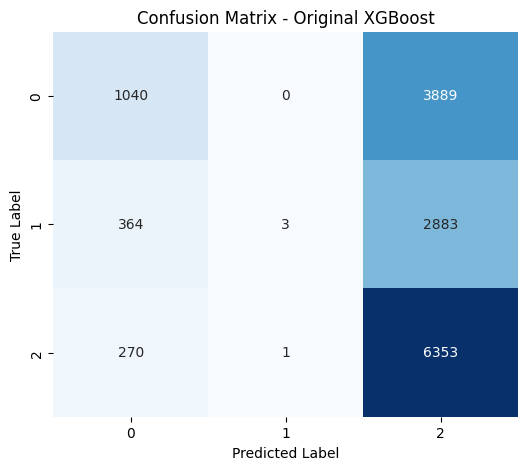

Classification Report - Original XGBoost
              precision    recall  f1-score   support

           0       0.62      0.21      0.32      4929
           1       0.75      0.00      0.00      3250
           2       0.48      0.96      0.64      6624

    accuracy                           0.50     14803
   macro avg       0.62      0.39      0.32     14803
weighted avg       0.59      0.50      0.39     14803



In [ ]:
cm_original = confusion_matrix(y_test, y_pred_test_xgb)

# Vẽ confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_original, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Original XGBoost")
plt.show()

# In classification report
print("Classification Report - Original XGBoost")
print(classification_report(y_test, y_pred_test_xgb))

Dựa vào biểu đồ confusion matrix và báo cáo phân loại từ mô hình XGBoost ban đầu, đây là một vài nhận xét:

- Lớp 2 (Đội nhà thắng - Home Win): Mô hình có vẻ hoạt động tốt nhất trong việc dự đoán khi đội nhà thắng.
  - Số lượng dự đoán đúng (True Label 2, Predicted Label 2) là 6353.
Recall (Tỷ lệ dự đoán đúng trên tổng số trường hợp thực tế thuộc lớp đó) rất cao (0.96). Điều này có nghĩa là mô hình xác định được 96% các trường hợp thực tế đội nhà thắng.
  - Tuy nhiên, Precision (Tỷ lệ dự đoán đúng trên tổng số trường hợp được dự đoán thuộc lớp đó) chỉ là 0.48. Điều này có nghĩa là khi mô hình dự đoán đội nhà thắng, chỉ có 48% trong số đó thực sự là đội nhà thắng, và 52% là dự đoán sai (thực tế là hòa hoặc đội khách thắng).
- Lớp 0 (Đội khách thắng - Away Win): Mô hình gặp khó khăn hơn trong việc dự đoán khi đội khách thắng.
  - Số lượng dự đoán đúng (True Label 0, Predicted Label 0) là 1040.
Recall thấp (0.21). Mô hình chỉ xác định được 21% các trường hợp thực tế đội khách thắng. Phần lớn các trường hợp đội khách thắng thực tế bị mô hình dự đoán sai là "Đội nhà thắng" (3889 trường hợp).
  - Precision (0.62) tốt hơn một chút so với lớp 2, nhưng vẫn có 38% dự đoán "Đội khách thắng" là sai.
- Lớp 1 (Hòa - Draw): Đây là lớp mà mô hình hoạt động kém nhất.
Chỉ có 3 trường hợp hòa được dự đoán đúng.
  - Recall cực kỳ thấp (0.00). Điều này có nghĩa là mô hình hầu như không thể xác định được bất kỳ trường hợp hòa thực tế nào.
  - Precision (0.75) có vẻ cao, nhưng con số này không đáng tin cậy do số lượng mẫu dự đoán thuộc lớp này quá ít (chỉ 4 trường hợp được dự đoán là hòa).

## Visual results

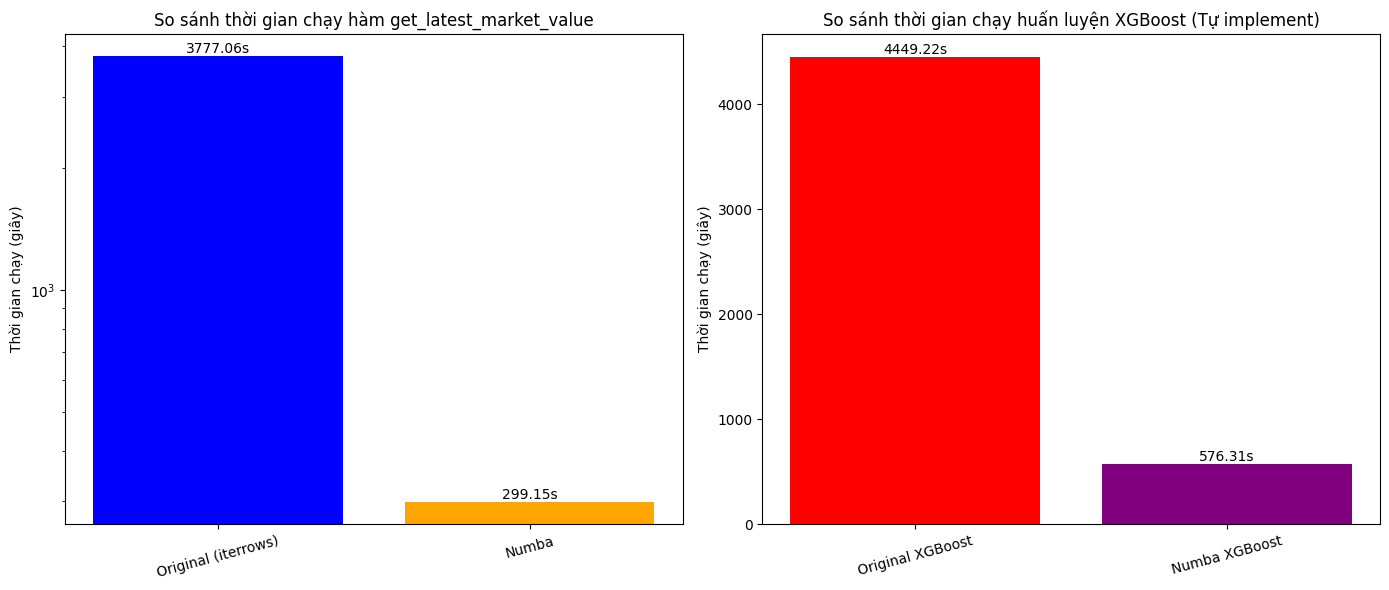

In [ ]:
market_value_runtimes = {
    'Original (iterrows)': total_elapsed_time,
    'Numba': total_elapsed_time_numba
}

xgboost_runtimes = {
    'Original XGBoost': training_time_xgb,
    'Numba XGBoost': training_time_numba_xgb
}

labels_mv = list(market_value_runtimes.keys())
values_mv = list(market_value_runtimes.values())

labels_xgb = list(xgboost_runtimes.keys())
values_xgb = list(xgboost_runtimes.values())

x_mv = np.arange(len(labels_mv))
x_xgb = np.arange(len(labels_xgb))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars_mv = axes[0].bar(x_mv, values_mv, color=['blue', 'orange', 'green'])
axes[0].set_ylabel('Thời gian chạy (giây)')
axes[0].set_title('So sánh thời gian chạy hàm get_latest_market_value')
axes[0].set_xticks(x_mv)
axes[0].set_xticklabels(labels_mv)
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_yscale('log')

for bar in bars_mv:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}s', va='bottom', ha='center')


bars_xgb = axes[1].bar(x_xgb, values_xgb, color=['red', 'purple'])
axes[1].set_ylabel('Thời gian chạy (giây)')
axes[1].set_title('So sánh thời gian chạy huấn luyện XGBoost (Tự implement)')
axes[1].set_xticks(x_xgb)
axes[1].set_xticklabels(labels_xgb)
axes[1].tick_params(axis='x', rotation=15)

for bar in bars_xgb:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}s', va='bottom', ha='center')


plt.tight_layout()
plt.show()

## Conclusion

Các biểu đồ cho thấy Numba là một công cụ cực kỳ mạnh mẽ để tăng tốc các tác vụ xử lý số chuyên sâu trên mảng NumPy, đặc biệt khi chúng có thể được song song hóa hiệu quả. Mức độ tăng tốc phụ thuộc vào bản chất của tác vụ và mức độ thành công trong việc chuyển đổi toàn bộ logic tính toán chuyên sâu sang mã Numba tương thích.
